# Dataset Bolonia

In [43]:
import pandas as pd
import numpy as np
import json
import os

import math

import seaborn as sns
import matplotlib.pyplot as plt
sns.set(color_codes=True)
%matplotlib inline

from sklearn import metrics

In [44]:
ruta_archivo_csv = "Old Datasets/Bolonia/dataset_5secondWindow.csv"

user1 = pd.read_csv(ruta_archivo_csv)
user1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5893 entries, 0 to 5892
Data columns (total 71 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Unnamed: 0                                       5893 non-null   int64  
 1   id                                               5893 non-null   int64  
 2   time                                             5893 non-null   float64
 3   activityrecognition#0                            0 non-null      float64
 4   activityrecognition#1                            5893 non-null   float64
 5   android.sensor.accelerometer#mean                5893 non-null   float64
 6   android.sensor.accelerometer#min                 5893 non-null   float64
 7   android.sensor.accelerometer#max                 5893 non-null   float64
 8   android.sensor.accelerometer#std                 5893 non-null   float64
 9   android.sensor.game_rotation_v

In [45]:
user1.head()

,Unnamed: 0,id,time,activityrecognition#0,activityrecognition#1,android.sensor.accelerometer#mean,android.sensor.accelerometer#min,android.sensor.accelerometer#max,android.sensor.accelerometer#std,android.sensor.game_rotation_vector#mean,...,sound#mean,sound#min,sound#max,sound#std,speed#mean,speed#min,speed#max,speed#std,target,user
0,0,16170,78.0,NaN,100.0,9.811476,9.758895,9.849411,0.014626,0.029340,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,Still,U12
1,1,15871,145.0,NaN,100.0,9.939207,7.707437,17.146631,1.775944,0.999925,...,89.200210,89.065143,89.335277,0.191013,16.539349,16.539349,16.539349,0.628595,Car,U12
2,2,16811,150.0,NaN,100.0,9.827178,9.804817,9.849262,0.011199,0.665215,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,Still,U12
3,3,15831,105.0,NaN,77.0,9.673039,7.659674,12.304298,0.862553,0.996221,...,87.470377,87.470377,87.470377,2.284186,17.739895,17.739895,17.739895,0.628595,Car,U12
4,4,876,77.0,NaN,100.0,9.993466,8.965621,10.891645,0.504117,0.563792,...,89.770732,89.770732,89.770732,0.006389,9.000000,9.000000,9.000000,NaN,Car,U1


#### Calculo de valores no nulos

In [46]:
# Agrupar por la columna "target" y calcular el número de datos no nulos por columna
counts = user1.groupby("target").count()

# Calcular la suma de valores nulos por columna
null_counts = user1.groupby("target").apply(lambda x: x.isnull().sum())

# Mostrar el número de datos no nulos
counts.head(20)

,Unnamed: 0,id,time,activityrecognition#0,activityrecognition#1,android.sensor.accelerometer#mean,android.sensor.accelerometer#min,android.sensor.accelerometer#max,android.sensor.accelerometer#std,android.sensor.game_rotation_vector#mean,...,android.sensor.step_counter#std,sound#mean,sound#min,sound#max,sound#std,speed#mean,speed#min,speed#max,speed#std,user
target,,,,,,,,,,,,,,,,,,,,,
Bus,1178,1178,1178,0,1178,1178,1178,1178,1178,1097,...,43,974,974,974,749,723,723,723,245,1178
Car,1180,1180,1180,0,1180,1180,1180,1180,1180,918,...,0,1008,1008,1008,904,1047,1047,1047,509,1180
Still,1179,1179,1179,0,1179,1179,1179,1179,1179,1055,...,0,859,859,859,777,664,664,664,324,1179
Train,1179,1179,1179,0,1179,1179,1179,1179,1179,1065,...,0,1068,1068,1068,945,250,250,250,90,1179
Walking,1177,1177,1177,0,1177,1177,1177,1177,1177,959,...,189,990,990,990,687,836,836,836,150,1177


# Preparación de los datos

#### Comprobación de las columnas del sensor Acelerómetro

In [47]:
# Rellenar los valores nulos con la media entre el valor anterior y posterior
user1[['android.sensor.accelerometer#mean', 'android.sensor.accelerometer#min', 'android.sensor.accelerometer#max', 'android.sensor.accelerometer#std']] = user1[['android.sensor.accelerometer#mean', 'android.sensor.accelerometer#min', 'android.sensor.accelerometer#max', 'android.sensor.accelerometer#std']].apply(lambda x: x.interpolate().fillna(method='bfill'))
user1.head()

,Unnamed: 0,id,time,activityrecognition#0,activityrecognition#1,android.sensor.accelerometer#mean,android.sensor.accelerometer#min,android.sensor.accelerometer#max,android.sensor.accelerometer#std,android.sensor.game_rotation_vector#mean,...,sound#mean,sound#min,sound#max,sound#std,speed#mean,speed#min,speed#max,speed#std,target,user
0,0,16170,78.0,NaN,100.0,9.811476,9.758895,9.849411,0.014626,0.029340,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,Still,U12
1,1,15871,145.0,NaN,100.0,9.939207,7.707437,17.146631,1.775944,0.999925,...,89.200210,89.065143,89.335277,0.191013,16.539349,16.539349,16.539349,0.628595,Car,U12
2,2,16811,150.0,NaN,100.0,9.827178,9.804817,9.849262,0.011199,0.665215,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,Still,U12
3,3,15831,105.0,NaN,77.0,9.673039,7.659674,12.304298,0.862553,0.996221,...,87.470377,87.470377,87.470377,2.284186,17.739895,17.739895,17.739895,0.628595,Car,U12
4,4,876,77.0,NaN,100.0,9.993466,8.965621,10.891645,0.504117,0.563792,...,89.770732,89.770732,89.770732,0.006389,9.000000,9.000000,9.000000,NaN,Car,U1


In [48]:
cantidad_nulos = user1[['android.sensor.accelerometer#mean', 'android.sensor.accelerometer#min', 'android.sensor.accelerometer#max', 'android.sensor.accelerometer#std']].isnull().sum()
print(cantidad_nulos)

android.sensor.accelerometer#mean    0
android.sensor.accelerometer#min     0
android.sensor.accelerometer#max     0
android.sensor.accelerometer#std     0
dtype: int64


#### Comprobación de las columnas del sensor Giroscopio

In [49]:
# Rellenar los valores nulos con la media entre el valor anterior y posterior
user1[['android.sensor.gyroscope#mean', 'android.sensor.gyroscope#min', 'android.sensor.gyroscope#max', 'android.sensor.gyroscope#std']] = user1[['android.sensor.gyroscope#mean', 'android.sensor.gyroscope#min', 'android.sensor.gyroscope#max', 'android.sensor.gyroscope#std']].apply(lambda x: x.interpolate().fillna(method='bfill'))
user1.head()

,Unnamed: 0,id,time,activityrecognition#0,activityrecognition#1,android.sensor.accelerometer#mean,android.sensor.accelerometer#min,android.sensor.accelerometer#max,android.sensor.accelerometer#std,android.sensor.game_rotation_vector#mean,...,sound#mean,sound#min,sound#max,sound#std,speed#mean,speed#min,speed#max,speed#std,target,user
0,0,16170,78.0,NaN,100.0,9.811476,9.758895,9.849411,0.014626,0.029340,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,Still,U12
1,1,15871,145.0,NaN,100.0,9.939207,7.707437,17.146631,1.775944,0.999925,...,89.200210,89.065143,89.335277,0.191013,16.539349,16.539349,16.539349,0.628595,Car,U12
2,2,16811,150.0,NaN,100.0,9.827178,9.804817,9.849262,0.011199,0.665215,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,Still,U12
3,3,15831,105.0,NaN,77.0,9.673039,7.659674,12.304298,0.862553,0.996221,...,87.470377,87.470377,87.470377,2.284186,17.739895,17.739895,17.739895,0.628595,Car,U12
4,4,876,77.0,NaN,100.0,9.993466,8.965621,10.891645,0.504117,0.563792,...,89.770732,89.770732,89.770732,0.006389,9.000000,9.000000,9.000000,NaN,Car,U1


In [50]:
cantidad_nulos = user1[['android.sensor.gyroscope#mean', 'android.sensor.gyroscope#min', 'android.sensor.gyroscope#max', 'android.sensor.gyroscope#std']].isnull().sum()
print(cantidad_nulos)

android.sensor.gyroscope#mean    0
android.sensor.gyroscope#min     0
android.sensor.gyroscope#max     0
android.sensor.gyroscope#std     0
dtype: int64


#### Comprobación de las columnas del sensor Magnetómetro

In [51]:
# Rellenar los valores nulos con la media entre el valor anterior y posterior
user1[['android.sensor.magnetic_field#mean','android.sensor.magnetic_field#min', 'android.sensor.magnetic_field#max', 'android.sensor.magnetic_field#std']] = user1[['android.sensor.magnetic_field#mean','android.sensor.magnetic_field#min', 'android.sensor.magnetic_field#max', 'android.sensor.magnetic_field#std']].apply(lambda x: x.interpolate().fillna(method='bfill'))
user1.head()

,Unnamed: 0,id,time,activityrecognition#0,activityrecognition#1,android.sensor.accelerometer#mean,android.sensor.accelerometer#min,android.sensor.accelerometer#max,android.sensor.accelerometer#std,android.sensor.game_rotation_vector#mean,...,sound#mean,sound#min,sound#max,sound#std,speed#mean,speed#min,speed#max,speed#std,target,user
0,0,16170,78.0,NaN,100.0,9.811476,9.758895,9.849411,0.014626,0.029340,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,Still,U12
1,1,15871,145.0,NaN,100.0,9.939207,7.707437,17.146631,1.775944,0.999925,...,89.200210,89.065143,89.335277,0.191013,16.539349,16.539349,16.539349,0.628595,Car,U12
2,2,16811,150.0,NaN,100.0,9.827178,9.804817,9.849262,0.011199,0.665215,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,Still,U12
3,3,15831,105.0,NaN,77.0,9.673039,7.659674,12.304298,0.862553,0.996221,...,87.470377,87.470377,87.470377,2.284186,17.739895,17.739895,17.739895,0.628595,Car,U12
4,4,876,77.0,NaN,100.0,9.993466,8.965621,10.891645,0.504117,0.563792,...,89.770732,89.770732,89.770732,0.006389,9.000000,9.000000,9.000000,NaN,Car,U1


In [52]:
cantidad_nulos = user1[['android.sensor.magnetic_field#mean','android.sensor.magnetic_field#min', 'android.sensor.magnetic_field#max', 'android.sensor.magnetic_field#std']].isnull().sum()
print(cantidad_nulos)

android.sensor.magnetic_field#mean    0
android.sensor.magnetic_field#min     0
android.sensor.magnetic_field#max     0
android.sensor.magnetic_field#std     0
dtype: int64


#### Comprobación de los sensores Barómetro 

In [53]:
# Rellenar los valores nulos con la media entre el valor anterior y posterior
user1[['android.sensor.pressure#mean','android.sensor.pressure#min', 'android.sensor.pressure#max', 'android.sensor.pressure#std']] = user1[['android.sensor.pressure#mean','android.sensor.pressure#min', 'android.sensor.pressure#max', 'android.sensor.pressure#std']].apply(lambda x: x.interpolate().fillna(method='bfill'))
user1.head()

,Unnamed: 0,id,time,activityrecognition#0,activityrecognition#1,android.sensor.accelerometer#mean,android.sensor.accelerometer#min,android.sensor.accelerometer#max,android.sensor.accelerometer#std,android.sensor.game_rotation_vector#mean,...,sound#mean,sound#min,sound#max,sound#std,speed#mean,speed#min,speed#max,speed#std,target,user
0,0,16170,78.0,NaN,100.0,9.811476,9.758895,9.849411,0.014626,0.029340,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,Still,U12
1,1,15871,145.0,NaN,100.0,9.939207,7.707437,17.146631,1.775944,0.999925,...,89.200210,89.065143,89.335277,0.191013,16.539349,16.539349,16.539349,0.628595,Car,U12
2,2,16811,150.0,NaN,100.0,9.827178,9.804817,9.849262,0.011199,0.665215,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,Still,U12
3,3,15831,105.0,NaN,77.0,9.673039,7.659674,12.304298,0.862553,0.996221,...,87.470377,87.470377,87.470377,2.284186,17.739895,17.739895,17.739895,0.628595,Car,U12
4,4,876,77.0,NaN,100.0,9.993466,8.965621,10.891645,0.504117,0.563792,...,89.770732,89.770732,89.770732,0.006389,9.000000,9.000000,9.000000,NaN,Car,U1


In [54]:
cantidad_nulos = user1[['android.sensor.pressure#mean','android.sensor.pressure#min', 'android.sensor.pressure#max', 'android.sensor.pressure#std']].isnull().sum()
print(cantidad_nulos)

android.sensor.pressure#mean    0
android.sensor.pressure#min     0
android.sensor.pressure#max     0
android.sensor.pressure#std     0
dtype: int64


#### Comprobación de los sensores de Luz

In [55]:
# Rellenar los valores nulos con la media entre el valor anterior y posterior
user1[['android.sensor.light#mean', 'android.sensor.light#min', 'android.sensor.light#max', 'android.sensor.light#std']] = user1[['android.sensor.light#mean', 'android.sensor.light#min', 'android.sensor.light#max', 'android.sensor.light#std']].apply(lambda x: x.interpolate().fillna(method='bfill'))
user1.head()

,Unnamed: 0,id,time,activityrecognition#0,activityrecognition#1,android.sensor.accelerometer#mean,android.sensor.accelerometer#min,android.sensor.accelerometer#max,android.sensor.accelerometer#std,android.sensor.game_rotation_vector#mean,...,sound#mean,sound#min,sound#max,sound#std,speed#mean,speed#min,speed#max,speed#std,target,user
0,0,16170,78.0,NaN,100.0,9.811476,9.758895,9.849411,0.014626,0.029340,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,Still,U12
1,1,15871,145.0,NaN,100.0,9.939207,7.707437,17.146631,1.775944,0.999925,...,89.200210,89.065143,89.335277,0.191013,16.539349,16.539349,16.539349,0.628595,Car,U12
2,2,16811,150.0,NaN,100.0,9.827178,9.804817,9.849262,0.011199,0.665215,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,Still,U12
3,3,15831,105.0,NaN,77.0,9.673039,7.659674,12.304298,0.862553,0.996221,...,87.470377,87.470377,87.470377,2.284186,17.739895,17.739895,17.739895,0.628595,Car,U12
4,4,876,77.0,NaN,100.0,9.993466,8.965621,10.891645,0.504117,0.563792,...,89.770732,89.770732,89.770732,0.006389,9.000000,9.000000,9.000000,NaN,Car,U1


In [56]:
cantidad_nulos = user1[['android.sensor.light#mean', 'android.sensor.light#min', 'android.sensor.light#max', 'android.sensor.light#std']].isnull().sum()
print(cantidad_nulos)

android.sensor.light#mean    0
android.sensor.light#min     0
android.sensor.light#max     0
android.sensor.light#std     0
dtype: int64


#### Número de valores de cada Actividad

In [57]:
# Contar la cantidad de ocurrencias de cada valor en la columna 'target'
conteo_valores = user1['target'].value_counts()

# Imprimir el resultado
print(conteo_valores)

Car        1180
Still      1179
Train      1179
Bus        1178
Walking    1177
Name: target, dtype: int64


In [58]:
change = {'Car':1, 'Still':2, 'Train':3, 'Bus':4, 'Walking':5}
user1['target'] = user1['target'].replace(change)

# Correlación de datos

In [59]:
# Calcular el valor absoluto de la correlación entre todas las columnas y la columna "target"
correlations = abs(user1.corr()['target'])

# Ordenar las correlaciones de mayor a menor
correlations = correlations.sort_values(ascending=False)

# Visualizar las correlaciones
print(correlations)

target                                        1.000000
android.sensor.gyroscope_uncalibrated#mean    0.570693
android.sensor.linear_acceleration#mean       0.544541
android.sensor.gyroscope_uncalibrated#max     0.542196
android.sensor.accelerometer#std              0.530662
                                                ...   
id                                            0.031250
android.sensor.pressure#std                   0.012833
android.sensor.light#std                      0.012606
Unnamed: 0                                    0.006815
activityrecognition#0                              NaN
Name: target, Length: 70, dtype: float64


## Matríz de correlación

Text(0.5, 1.0, 'Correlation Matrix')

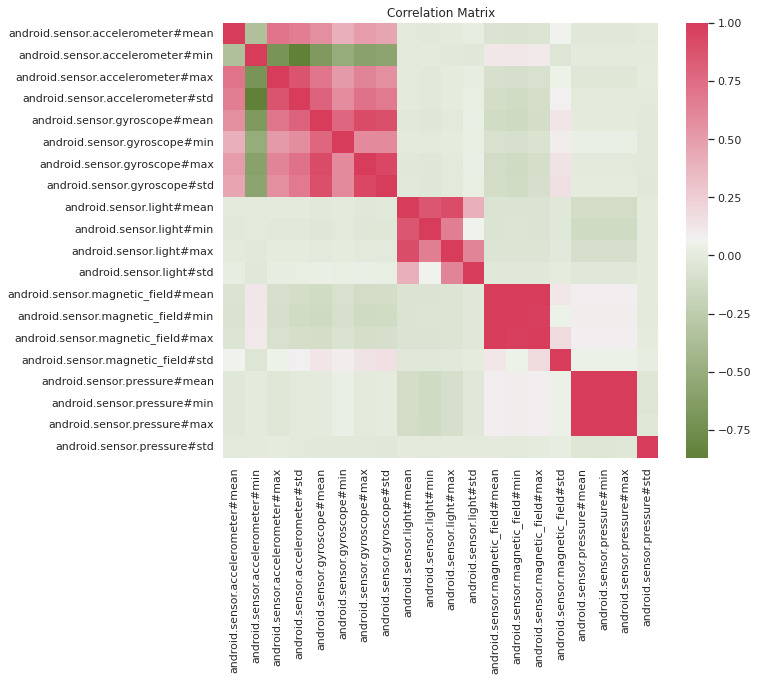

In [60]:
# Correlation matrix
CorrInfo = pd.DataFrame(user1,columns=['android.sensor.accelerometer#mean','android.sensor.accelerometer#min', 'android.sensor.accelerometer#max', 'android.sensor.accelerometer#std', 'android.sensor.gyroscope#mean', 'android.sensor.gyroscope#min', 'android.sensor.gyroscope#max', 'android.sensor.gyroscope#std', 'android.sensor.light#mean', 'android.sensor.light#min', 'android.sensor.light#max', 'android.sensor.light#std','android.sensor.magnetic_field#mean', 'android.sensor.magnetic_field#min','android.sensor.magnetic_field#max', 'android.sensor.magnetic_field#std','android.sensor.pressure#mean', 'android.sensor.pressure#min','android.sensor.pressure#max','android.sensor.pressure#std'  ])

f, ax = plt.subplots(figsize=(10, 8))
corr = CorrInfo.corr()
sns.heatmap(corr, mask=np.zeros_like(corr, dtype=bool), cmap=sns.diverging_palette(110, 5, as_cmap=True),
            square=True, ax=ax)
plt.title("Correlation Matrix")

# Modelo de red neuronal

In [61]:
features = ['android.sensor.accelerometer#mean','android.sensor.accelerometer#min', 'android.sensor.accelerometer#max', 'android.sensor.accelerometer#std', 'android.sensor.gyroscope#mean', 'android.sensor.gyroscope#min', 'android.sensor.gyroscope#max', 'android.sensor.gyroscope#std', 'android.sensor.light#mean', 'android.sensor.light#min', 'android.sensor.light#max', 'android.sensor.light#std','android.sensor.magnetic_field#mean', 'android.sensor.magnetic_field#min','android.sensor.magnetic_field#max', 'android.sensor.magnetic_field#std','android.sensor.pressure#mean', 'android.sensor.pressure#min','android.sensor.pressure#max','android.sensor.pressure#std'  ]

In [62]:
X_orig = user1[features]
y = user1['target']

RANDOM_STATE = 10
numero_de_filas, numero_de_columnas = X_orig.shape

print("Número de filas:", numero_de_filas)
print("Número de columnas:", numero_de_columnas)

Número de filas: 5893
Número de columnas: 20


In [63]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dropout

# Paso 1: Definir los datos de entrada y las etiquetas
X_orig = user1[features]
y = user1['target']

# Paso 2: Separar características y variable objetivo
X = X_orig.to_numpy()

# Paso 3: Codificar etiquetas con LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Paso 4: Codificar etiquetas en formato one-hot
onehot_encoder = OneHotEncoder(sparse=False)
y_onehot = onehot_encoder.fit_transform(y_encoded.reshape(-1, 1))

# Paso 5: Dividir datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# Paso 6: Ajustar forma de los datos para LSTM y convertir a tipo float
X_train = X_train.astype(float)
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.astype(float)
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

# Paso 7: Crear modelo LSTM
model = Sequential()
model.add(LSTM(256, input_shape=(1, X_train.shape[2]), return_sequences=True))
model.add(LSTM(128))
model.add(Dense(5, activation='softmax'))


# Paso 8: Compilar y entrenar modelo LSTM
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_test, y_test))


2023-08-30 21:10:22.569678: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-08-30 21:10:22.591963: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-08-30 21:10:22.771338: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-08-30 21:10:22.771895: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-08-30 21:10:25.082041: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not fin

Epoch 1/20


2023-08-30 21:10:29.284492: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-08-30 21:10:29.285732: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-08-30 21:10:29.286678: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

69/74 [==========================>...] - ETA: 0s - loss: 1.4641 - accuracy: 0.3435

2023-08-30 21:10:31.841498: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-08-30 21:10:31.842880: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-08-30 21:10:31.843680: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

74/74 [==============================] - 3s 13ms/step - loss: 1.4607 - accuracy: 0.3460 - val_loss: 1.3852 - val_accuracy: 0.3571
Epoch 2/20
74/74 [==============================] - 0s 6ms/step - loss: 1.3635 - accuracy: 0.4094 - val_loss: 1.3287 - val_accuracy: 0.5072
Epoch 3/20
74/74 [==============================] - 0s 6ms/step - loss: 1.3158 - accuracy: 0.4419 - val_loss: 1.2413 - val_accuracy: 0.4962
Epoch 4/20
74/74 [==============================] - 0s 6ms/step - loss: 1.2072 - accuracy: 0.5140 - val_loss: 1.2153 - val_accuracy: 0.4741
Epoch 5/20
74/74 [==============================] - 0s 6ms/step - loss: 1.1593 - accuracy: 0.5384 - val_loss: 1.1634 - val_accuracy: 0.4750
Epoch 6/20
74/74 [==============================] - 0s 7ms/step - loss: 1.1399 - accuracy: 0.5403 - val_loss: 1.1145 - val_accuracy: 0.5615
Epoch 7/20
74/74 [==============================] - 0s 6ms/step - loss: 1.1062 - accuracy: 0.5596 - val_loss: 1.0573 - val_accuracy: 0.5861
Epoch 8/20
74/74 [============

In [64]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Realizar las predicciones en el conjunto de prueba
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Decodificar las etiquetas predichas
y_pred_labels_decoded = label_encoder.inverse_transform(y_pred_labels)

# Decodificar las etiquetas reales
y_test_labels = onehot_encoder.inverse_transform(y_test)
y_test_labels_decoded = label_encoder.inverse_transform(y_test_labels)

# Calcular las métricas de evaluación
accuracy = np.mean(y_pred_labels_decoded == y_test_labels_decoded)
precision = precision_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')
recall = recall_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')
f1 = f1_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')

# Imprimir los resultados
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

2023-08-30 21:11:01.887610: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-08-30 21:11:01.888771: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-08-30 21:11:01.889878: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

37/37 [==============================] - 0s 2ms/step
Accuracy: 0.5979643765903307
Precision: 0.6106719775467195
Recall: 0.5979643765903307
F1 Score: 0.5859409348534838


/home/ricardo.casanova/.local/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:155: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
Car        1180
Still      1179
Train      1179
Bus        1178
Walking    1177

In [66]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Labels=['Conducir coche', 'Estar detenido', 'Metro', 'Bus', 'Caminar']

# Realizar las predicciones en el conjunto de prueba
y_pred_probabilities = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_probabilities, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Decodificar las etiquetas predichas y reales
y_pred_labels_decoded = label_encoder.inverse_transform(y_pred_labels)
y_test_labels = onehot_encoder.inverse_transform(y_test)
y_test_labels_decoded = label_encoder.inverse_transform(y_test_labels)

# Calcular las métricas de evaluación para cada etiqueta
num_labels = len(label_encoder.classes_)
accuracy_per_label = []
precision_per_label = []
recall_per_label = []
f1_per_label = []

for label_idx in range(num_labels):
    y_true_label = (y_test_labels_decoded == label_encoder.classes_[label_idx]).astype(int)
    y_pred_label = (y_pred_labels_decoded == label_encoder.classes_[label_idx]).astype(int)

    accuracy_per_label.append(accuracy_score(y_true_label, y_pred_label))
    precision_per_label.append(precision_score(y_true_label, y_pred_label))
    recall_per_label.append(recall_score(y_true_label, y_pred_label))
    f1_per_label.append(f1_score(y_true_label, y_pred_label))

# Imprimir los resultados por etiqueta
for label_idx in range(num_labels):
    print(f'Label: {label_encoder.classes_[label_idx]}, {Labels[label_idx]}')
    print('Accuracy:', accuracy_per_label[label_idx])
    print('Precision:', precision_per_label[label_idx])
    print('Recall:', recall_per_label[label_idx])
    print('F1 Score:', f1_per_label[label_idx])
    print()

37/37 [==============================] - 0s 2ms/step
Label: 1, Conducir coche
Accuracy: 0.823579304495335
Precision: 0.6495726495726496
Recall: 0.31275720164609055
F1 Score: 0.4222222222222223

Label: 2, Estar detenido
Accuracy: 0.7896522476675149
Precision: 0.5
Recall: 0.717741935483871
F1 Score: 0.5894039735099338

Label: 3, Metro
Accuracy: 0.8320610687022901
Precision: 0.574750830564784
Recall: 0.7119341563786008
F1 Score: 0.6360294117647057

Label: 4, Bus
Accuracy: 0.8244274809160306
Precision: 0.4423076923076923
Recall: 0.36507936507936506
F1 Score: 0.39999999999999997

Label: 5, Caminar
Accuracy: 0.926208651399491
Precision: 0.8393574297188755
Recall: 0.81640625
F1 Score: 0.8277227722772277



/home/ricardo.casanova/.local/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:155: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


## Matriz de confusión

<function matplotlib.pyplot.show(close=None, block=None)>

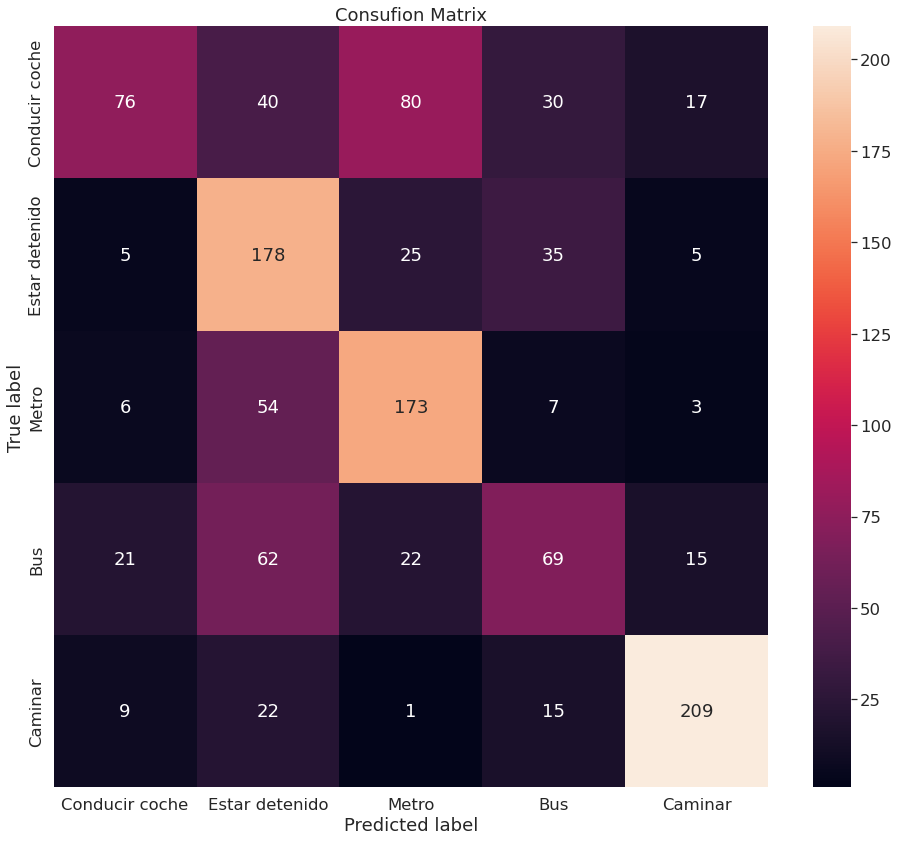

In [67]:
confusion_matrix = metrics.confusion_matrix(y_true=y_true_labels, y_pred=y_pred_labels)

plt.figure(figsize=(16,14))
sns.set(style='whitegrid', palette='muted', font_scale=1.5)
sns.heatmap(confusion_matrix, xticklabels=Labels, yticklabels=Labels, annot=True,fmt='d')
plt.title('Consufion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show


In [68]:
# Obtener los valores únicos y sus conteos
valores, conteos = np.unique(y_true_labels, return_counts=True)

#Imprimir el resultado
for valor, conteo, label in zip(valores, conteos, Labels):
    print(f"Valor: {valor}, Cantidad: {conteo}, Actividad: {label}")

Valor: 0, Cantidad: 243, Actividad: Conducir coche
Valor: 1, Cantidad: 248, Actividad: Estar detenido
Valor: 2, Cantidad: 243, Actividad: Metro
Valor: 3, Cantidad: 189, Actividad: Bus
Valor: 4, Cantidad: 256, Actividad: Caminar


# Exportamos el modelo

In [70]:
import joblib
# Guardamos el modelo entrenado
filename = 'Modelos/model_Bolonia.pkl' # Nombre del archivo donde se guardará el modelo
joblib.dump(model, filename) # Guardamos el modelo en un archivo
joblib.dump(label_encoder, 'Label/label_encoder_Bolonia.pkl')  # Guardar el LabelEncoder

['Label/label_encoder_Bolonia.pkl']